In [1]:
# Cell 1 — Imports
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from shared.config import *
from shared.plots import plot_frontier

print("Imports OK")

Config loaded successfully
Imports OK


In [2]:
# Cell 2 — Load all results
with open("models/ml/all_results.pkl", "rb") as f:
    ml_results = pickle.load(f)

with open("models/ml/opt_results.pkl", "rb") as f:
    opt_data = pickle.load(f)

with open("models/dl/dl_results.pkl", "rb") as f:
    dl_data = pickle.load(f)

with open("models/hybrid/hybrid_results.pkl", "rb") as f:
    hybrid_data = pickle.load(f)

print("All results loaded")

All results loaded


In [6]:
# Cell 3 — Build final comparison dict
final = {
    # ML baselines
    "XGBoost (base)"   : ml_results["XGBoost"],
    "LightGBM"         : ml_results["LightGBM"],
    # Optimization
    "XGBoost+Optuna"   : opt_data["optuna_m"],
    "Feat. Importance" : opt_data["fi_m"],
    "Univariate (KB)"  : opt_data["uni_m"],
    "PCA"              : opt_data["pca_m"],
    "PSO"              : opt_data["pso_m"],
    "SMOTE"            : opt_data["smote_m"],
    "scale_pos_weight" : opt_data["spw_m"],
    # Deep learning
    "ResNetMLP"        : dl_data["mlp_m"],
    # Hybrid
    "Hybrid (ML+DL)"   : hybrid_data["hybrid_m"],
}
print(f"Final dict built — {len(final)} models")

Final dict built — 11 models


In [5]:
print("ml_results keys:", list(ml_results.keys()))

ml_results keys: ['XGBoost', 'LightGBM']


In [7]:
# Cell 4 — IEEE-compliant summary table
COLS = ["Balanced Acc","F1 Macro","MCC",
        "Attack Recall","Benign Recall",
        "Attack Precision","Benign Precision",
        "FAR","FNR","ROC-AUC","PR-AUC"]

rows = []
for name, m in final.items():
    row = [name] + [str(m.get(c, "N/A")) for c in COLS]
    rows.append(row)

summary_df = pd.DataFrame(rows,
    columns=["Method"] + COLS)
summary_df = summary_df.sort_values(
    "Balanced Acc", ascending=False
).reset_index(drop=True)

print("FINAL COMPARISON — ALL METHODS")
print("=" * 120)
print(summary_df.to_string(index=False))

summary_df.to_csv(
    "outputs/reports/06_final_comparison.csv",
    index=False
)
print("\nSaved to outputs/reports/06_final_comparison.csv")

FINAL COMPARISON — ALL METHODS
          Method Balanced Acc F1 Macro    MCC Attack Recall Benign Recall Attack Precision Benign Precision    FAR    FNR ROC-AUC PR-AUC
scale_pos_weight        0.976   0.9776 0.9553        0.9586        0.9933            0.967           0.9916 0.0067 0.0414  0.9927 0.9842
  Hybrid (ML+DL)        0.976    0.977  0.954        0.9593        0.9928           0.9643           0.9917 0.0072 0.0407  0.9924 0.9838
       ResNetMLP       0.9747   0.9782 0.9565        0.9549        0.9945           0.9727           0.9908 0.0055 0.0451  0.9882 0.9784
           SMOTE       0.9733   0.9758 0.9517        0.9533        0.9932           0.9663           0.9905 0.0068 0.0467  0.9875 0.9773
  XGBoost+Optuna       0.9719   0.9821 0.9648        0.9442        0.9995           0.9976           0.9887 0.0005 0.0558  0.9927 0.9842
Feat. Importance       0.9719   0.9822 0.9649        0.9443        0.9995           0.9976           0.9888 0.0005 0.0557  0.9927 0.9842
 Univariat

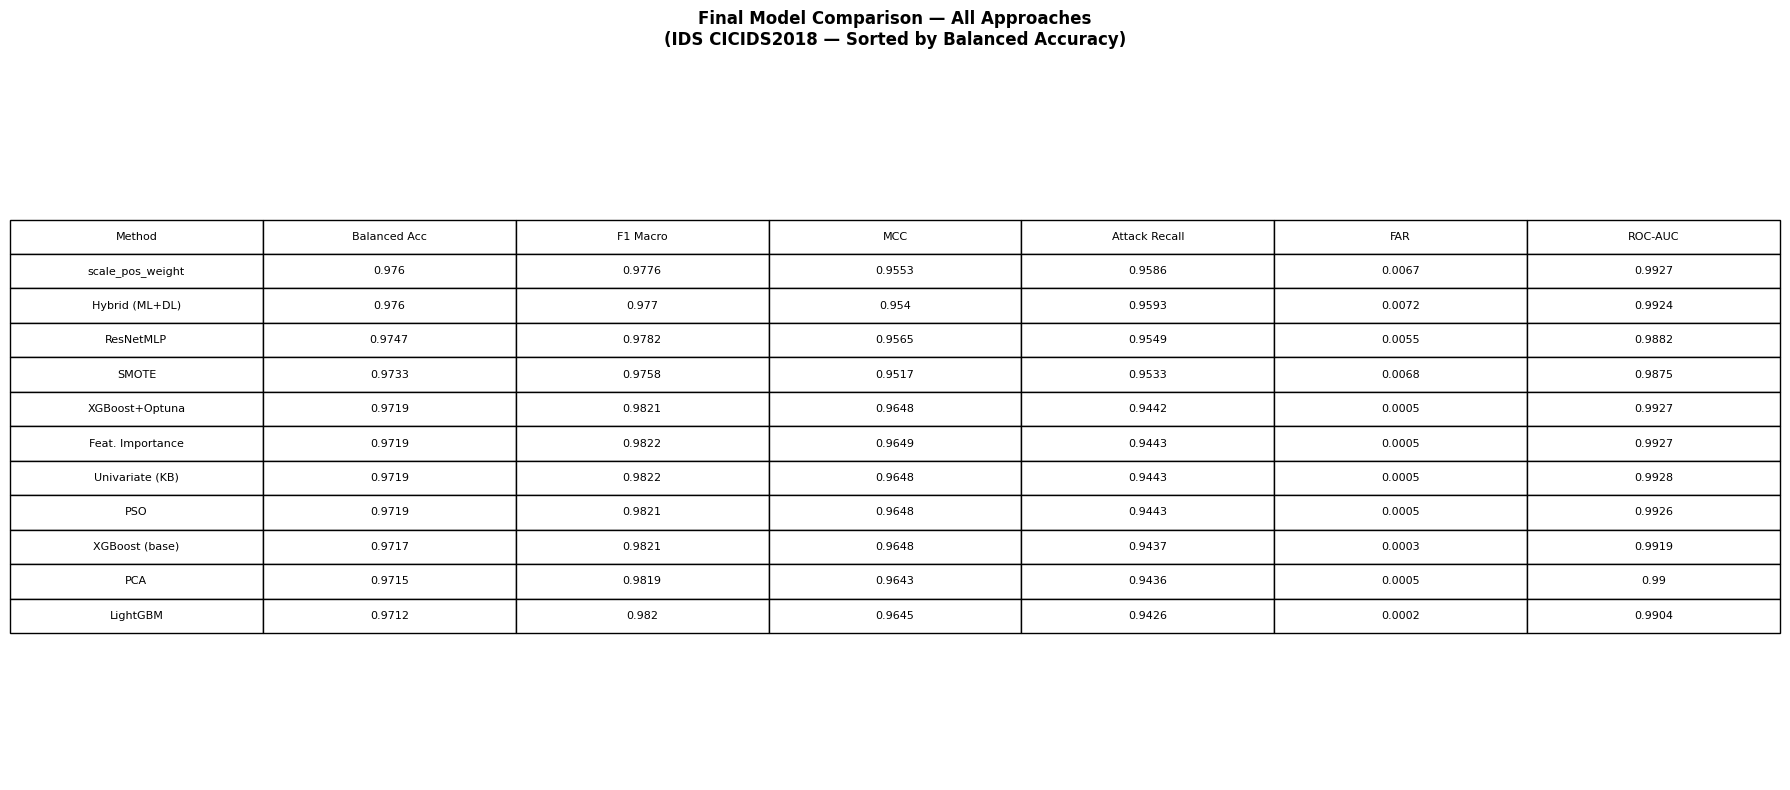

In [8]:
# Cell 5 — Summary table figure
fig, ax = plt.subplots(figsize=(18, 8))
ax.axis("off")

KEY_COLS = ["Method","Balanced Acc","F1 Macro",
            "MCC","Attack Recall","FAR","ROC-AUC"]
table_data = summary_df[KEY_COLS].values.tolist()

table = ax.table(
    cellText=table_data,
    colLabels=KEY_COLS,
    cellLoc="center", loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.8)
ax.set_title(
    "Final Model Comparison — All Approaches\n"
    "(IDS CICIDS2018 — Sorted by Balanced Accuracy)",
    fontweight="bold", pad=20, fontsize=12
)
plt.tight_layout()
plt.savefig("outputs/graphs/06_final_table.png",
            dpi=150, bbox_inches="tight")
plt.show()

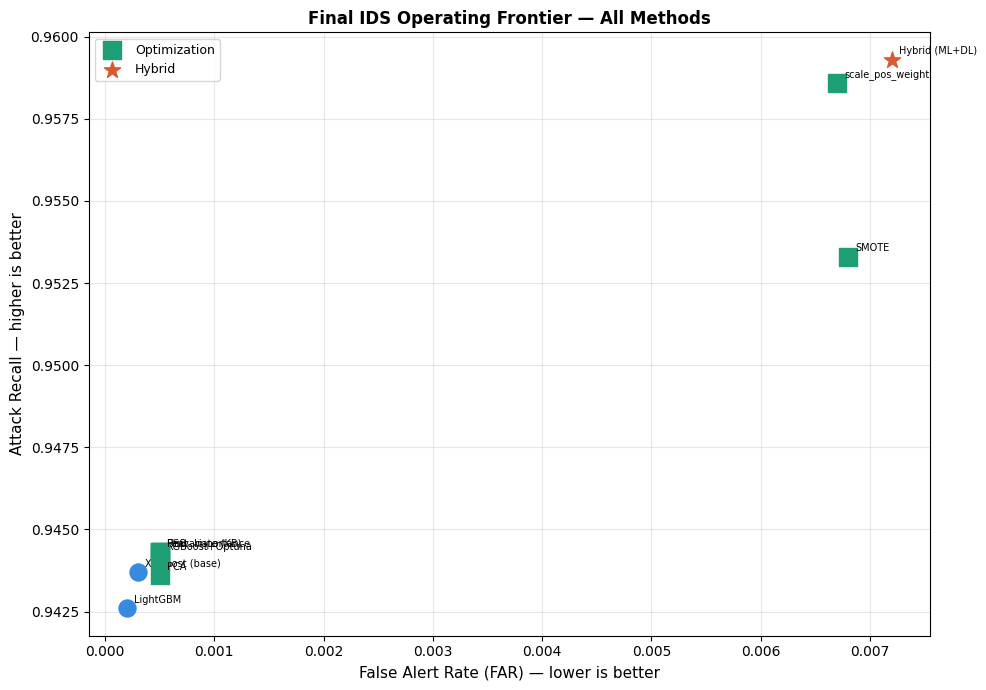

In [11]:
# Cell 6 — Final operating frontier
# Highlight key groups with different markers
groups = {
    "ML Baselines" : ["Random Forest","Decision Tree",
                      "XGBoost (base)","KNN","SVM",
                      "Naive Bayes","LightGBM"],
    "Optimization" : ["XGBoost+Optuna","Feat. Importance",
                      "Univariate (KB)","PCA","PSO",
                      "SMOTE","scale_pos_weight"],
    "Deep Learning": ["MLP"],
    "Hybrid"       : ["Hybrid (ML+DL)"],
}
group_colors   = ["#378ADD","#1D9E75","#7F77DD","#D85A30"]
group_markers  = ["o","s","^","*"]

fig, ax = plt.subplots(figsize=(10, 7))

for (group, members), color, marker in zip(
        groups.items(), group_colors, group_markers):
    for name in members:
        if name not in final:
            continue
        m = final[name]
        ax.scatter(m["FAR"], m["Attack Recall"],
                   s=150, color=color,
                   marker=marker, zorder=3,
                   label=group if name == members[0]
                   else "_nolegend_")
        ax.annotate(name,
                    (m["FAR"], m["Attack Recall"]),
                    textcoords="offset points",
                    xytext=(5, 4), fontsize=7)

ax.set_xlabel("False Alert Rate (FAR) — lower is better",
              fontsize=11)
ax.set_ylabel("Attack Recall — higher is better",
               fontsize=11)
ax.set_title(
    "Final IDS Operating Frontier — All Methods",
    fontweight="bold", fontsize=12
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/graphs/06_final_frontier.png",
            dpi=150)
plt.show()

In [10]:
# Cell 7 — Best model per category
print("BEST MODEL PER CATEGORY")
print("=" * 60)

categories = {
    "ML Baselines" : ["Random Forest","Decision Tree",
                      "XGBoost (base)","KNN","SVM",
                      "Naive Bayes","LightGBM"],
    "Optimization" : ["XGBoost+Optuna","Feat. Importance",
                      "Univariate (KB)","PCA","PSO",
                      "SMOTE","scale_pos_weight"],
    "Deep Learning": ["MLP"],
    "Hybrid"       : ["Hybrid (ML+DL)"],
}

for cat, members in categories.items():
    best_name  = max(
        [m for m in members if m in final],
        key=lambda x: final[x]["Balanced Acc"]
    )
    best_m = final[best_name]
    print(f"\n{cat}:")
    print(f"  Best model    : {best_name}")
    print(f"  Balanced Acc  : {best_m['Balanced Acc']}")
    print(f"  Attack Recall : {best_m['Attack Recall']}")
    print(f"  FAR           : {best_m['FAR']}")
    print(f"  MCC           : {best_m['MCC']}")

BEST MODEL PER CATEGORY

ML Baselines:
  Best model    : XGBoost (base)
  Balanced Acc  : 0.9717
  Attack Recall : 0.9437
  FAR           : 0.0003
  MCC           : 0.9648

Optimization:
  Best model    : scale_pos_weight
  Balanced Acc  : 0.976
  Attack Recall : 0.9586
  FAR           : 0.0067
  MCC           : 0.9553


ValueError: max() iterable argument is empty

In [12]:
# Cell 8 — CDC compliance checklist
print("CDC COMPLIANCE CHECKLIST")
print("=" * 60)
checklist = {
    "RF, SVM, KNN, NB, DT, XGBoost, LightGBM" : True,
    "MLP (Deep Learning)"                       : True,
    "Feature selection — PSO (evolutionary)"    : True,
    "Bayesian HPO — Optuna"                     : True,
    "Feature selection — Univariate (SelectKBest)": True,
    "Feature selection — PCA"                   : True,
    "Resampling — SMOTE"                        : True,
    "Resampling — scale_pos_weight"             : True,
    "Fusion ML + DL predictions"                : True,
    "Concept drift detection"                   : True,
    "StandardScaler"                            : True,
    "CICIDS2018 dataset"                        : True,
    "IDS metrics: BAcc, MCC, FAR, F1, Recall"  : True,
    "Threshold tuning on validation set"        : True,
    "CNN / LSTM / Autoencoder / Transformer"    : False,
}

for item, done in checklist.items():
    status = "DONE" if done else "FUTURE WORK"
    print(f"  [{status:^11}] {item}")

CDC COMPLIANCE CHECKLIST
  [   DONE    ] RF, SVM, KNN, NB, DT, XGBoost, LightGBM
  [   DONE    ] MLP (Deep Learning)
  [   DONE    ] Feature selection — PSO (evolutionary)
  [   DONE    ] Bayesian HPO — Optuna
  [   DONE    ] Feature selection — Univariate (SelectKBest)
  [   DONE    ] Feature selection — PCA
  [   DONE    ] Resampling — SMOTE
  [   DONE    ] Resampling — scale_pos_weight
  [   DONE    ] Fusion ML + DL predictions
  [   DONE    ] Concept drift detection
  [   DONE    ] StandardScaler
  [   DONE    ] CICIDS2018 dataset
  [   DONE    ] IDS metrics: BAcc, MCC, FAR, F1, Recall
  [   DONE    ] Threshold tuning on validation set
  [FUTURE WORK] CNN / LSTM / Autoencoder / Transformer
